In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
y = iris.target

In [5]:
# take first two features

X = X[:,:2]

X.shape

(150, 2)

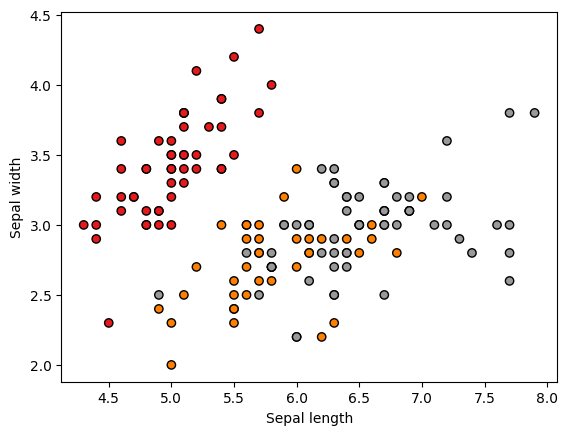

In [6]:
# Visualize the raw data

plt.scatter(X[:,0], X[:,1],c = y, cmap = plt.cm.Set1, edgecolor = 'k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X,y)

KNeighborsClassifier()

In [42]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X)
accuracy_score(y,y_pred)

0.84

### How do we draw the decision boundary

*   Cover the entire feature space with tiny grid points

* Predict class for each grid point

* Color the regions

* The color change line = decision boundary




In [8]:
# Create a mesh grid

x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

In [9]:
xx,yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

In [11]:
# Predict class for each grid point

grid_points = np.c_[xx.ravel(),yy.ravel()]
Z = knn.predict(grid_points)
Z = Z.reshape(xx.shape)
Z

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2]])

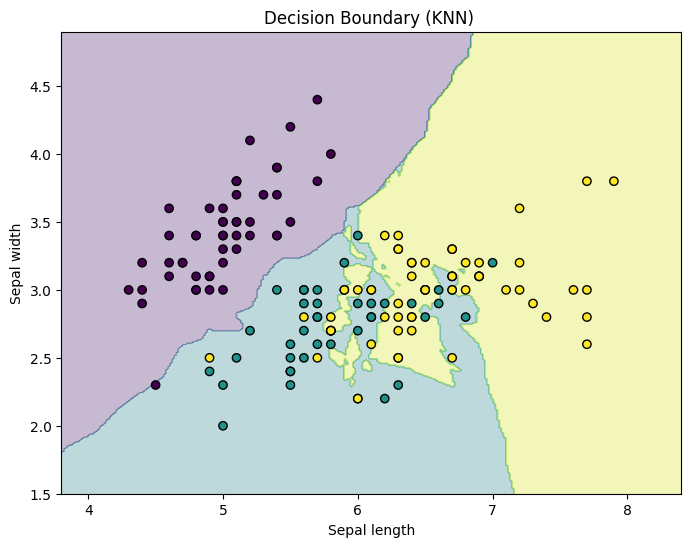

In [13]:
# Plot decision boundary

plt.figure(figsize = (8,6))

# Decision regions
plt.contourf(xx, yy, Z, alpha = 0.3)

# Actual data points
plt.scatter(X[:,0], X[:,1],c = y, edgecolor = 'k')

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title("Decision Boundary (KNN) ")
plt.show()

### Effect of K (overfitting vs underfitting)

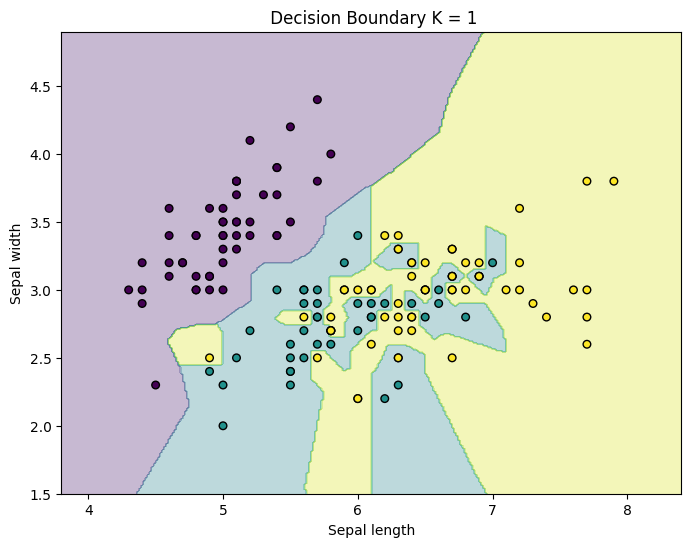

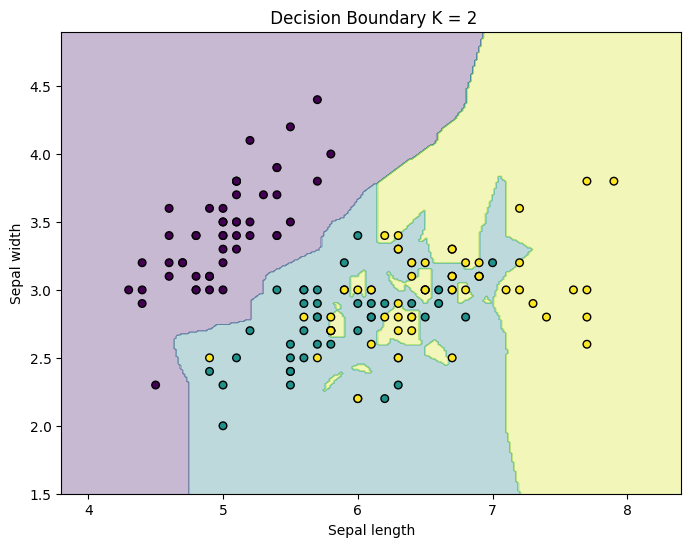

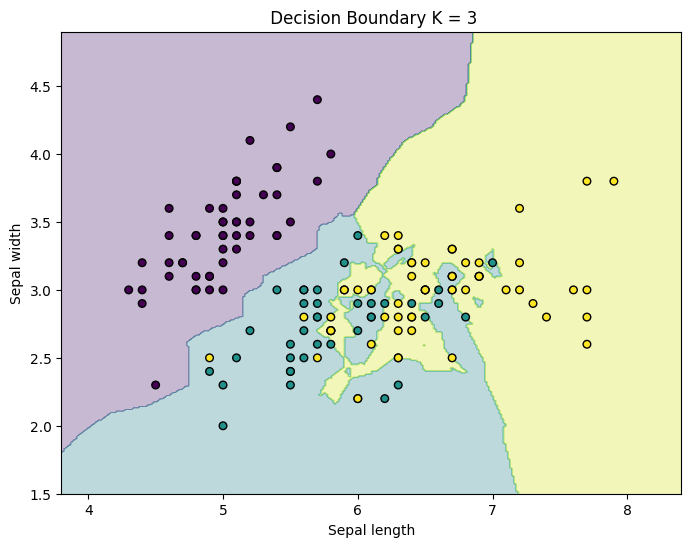

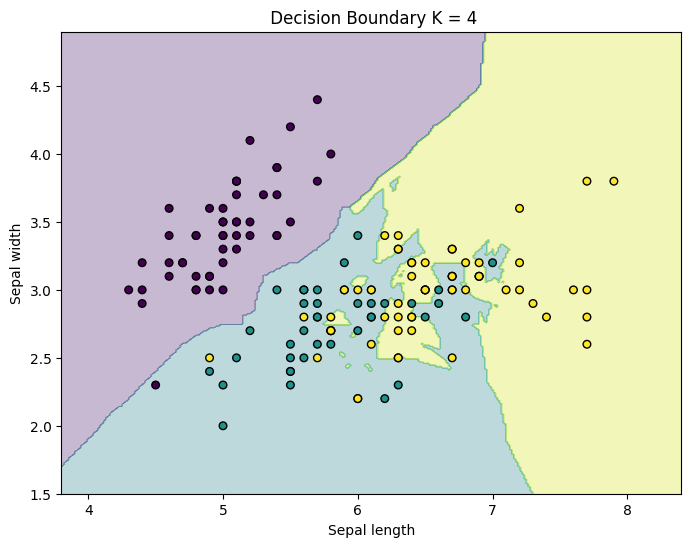

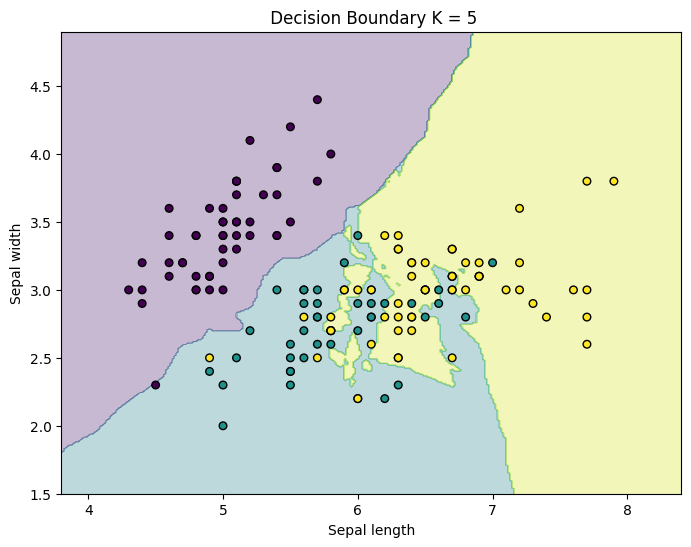

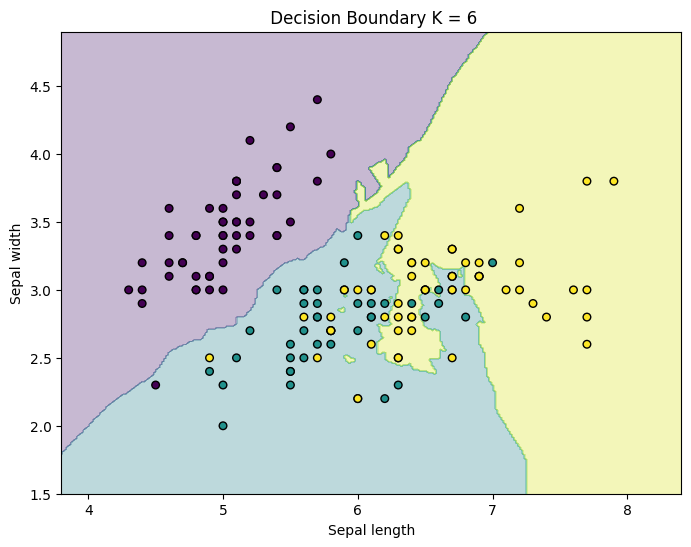

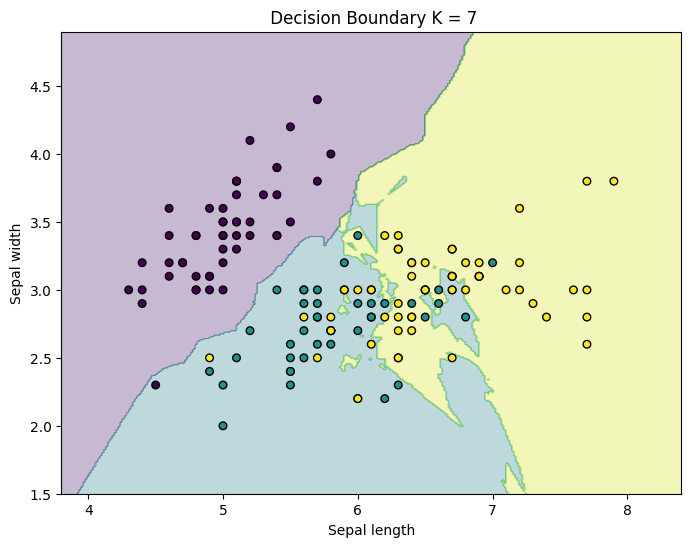

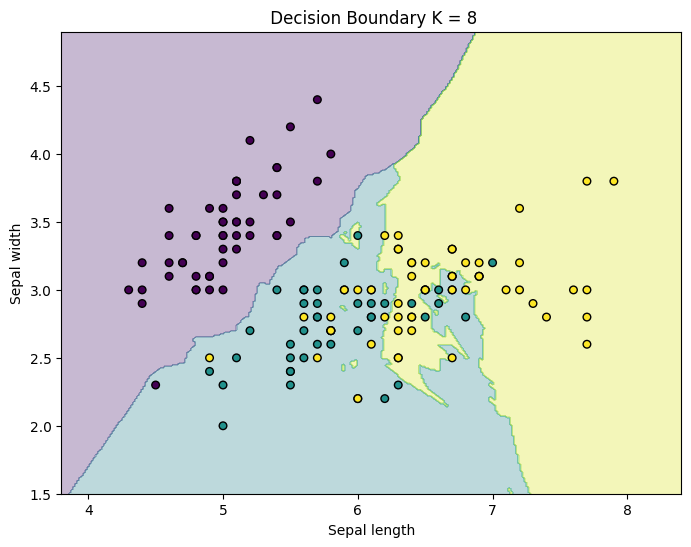

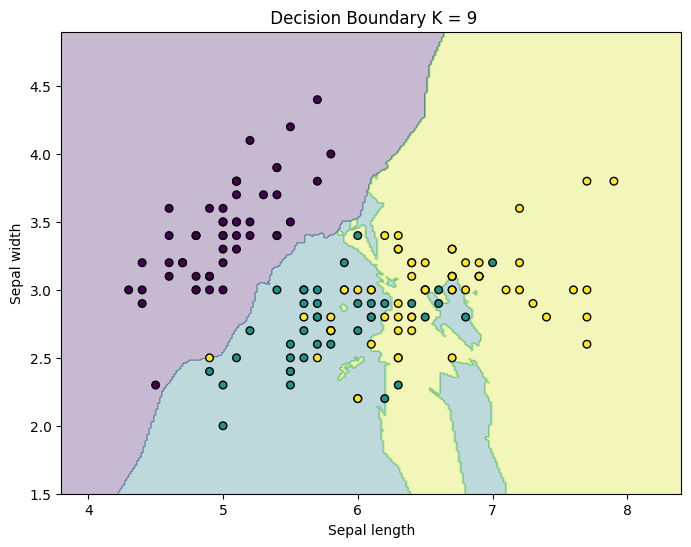

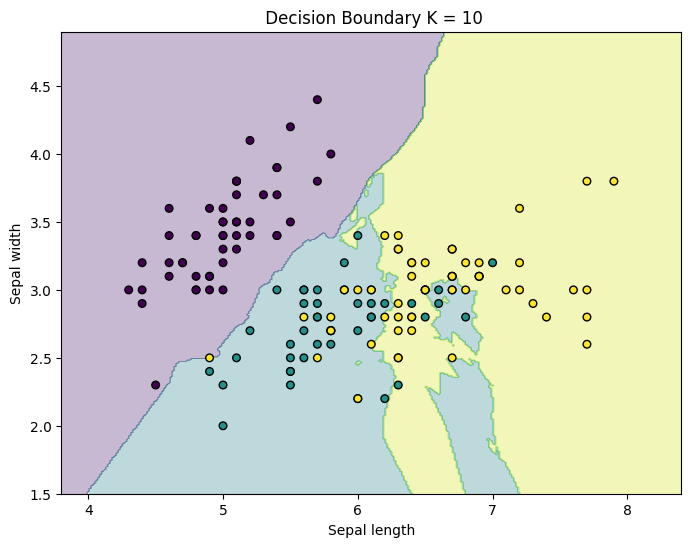

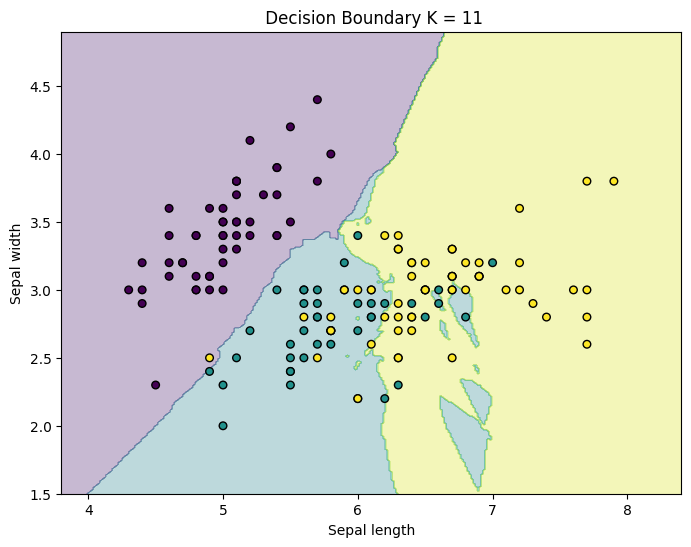

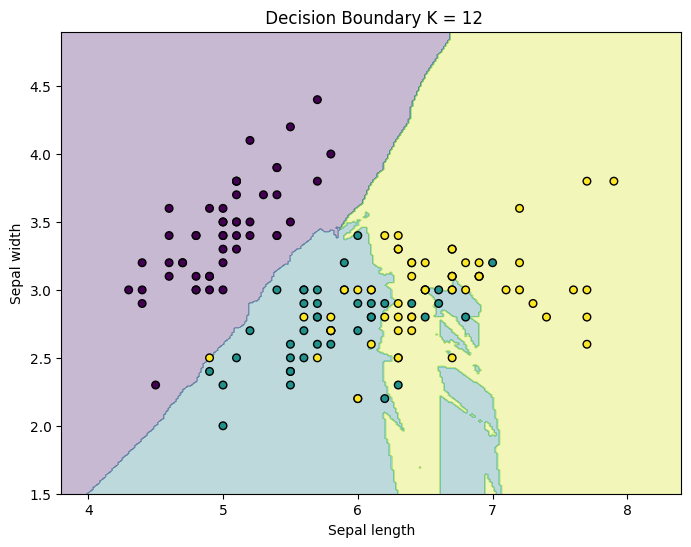

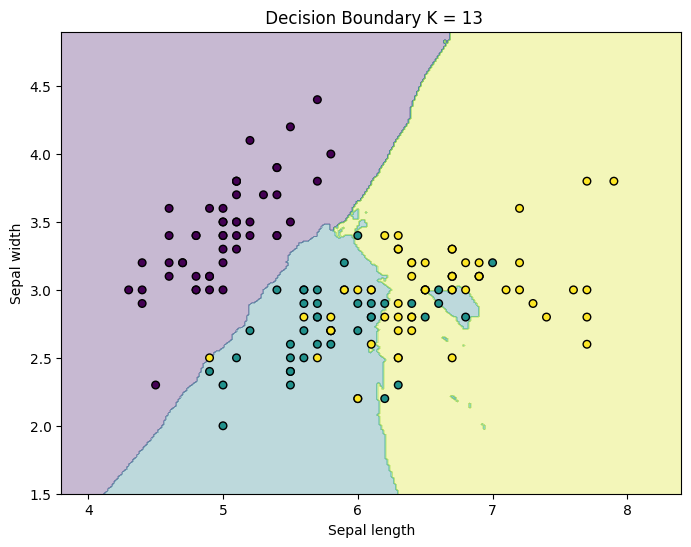

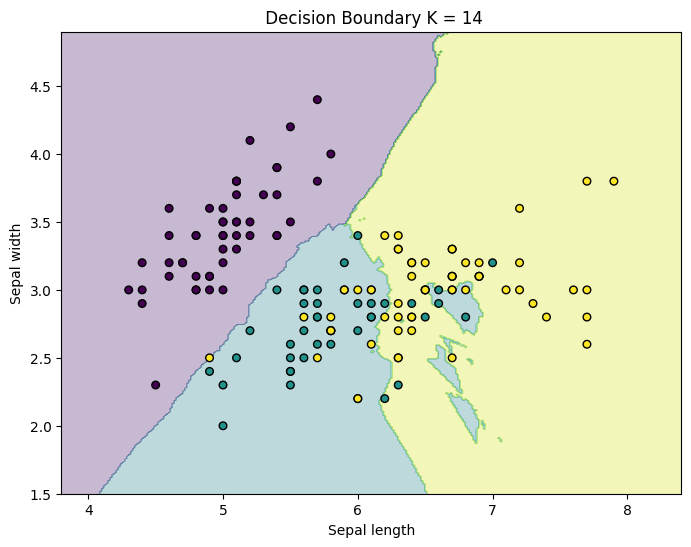

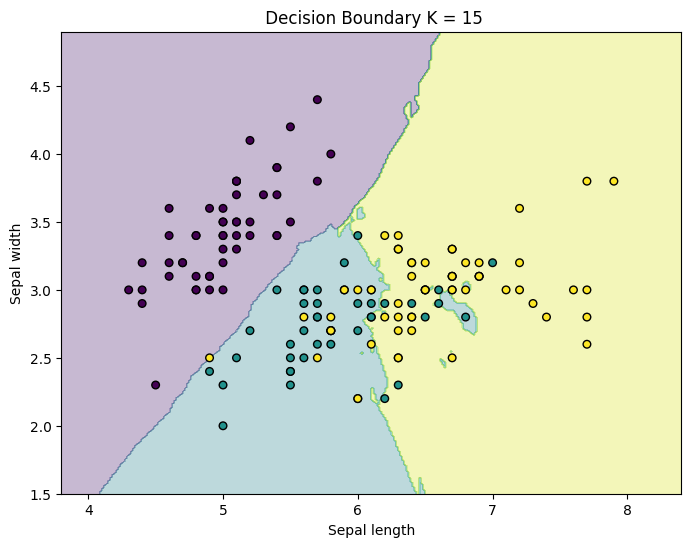

In [25]:

for k in range(1,16):
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(X,y)


  Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.figure(figsize = (8,6))

  # Decision regions


  plt.contourf(xx, yy, Z, alpha = 0.3)

  plt.scatter(X[:,0], X[:,1], c= y, edgecolor = 'k',s = 30)
  plt.xlabel('Sepal length')
  plt.ylabel('Sepal width')
  plt.title(f" Decision Boundary K = {k}")
  plt.show()
